# Análisis RFM 
#### **Entendimiento del comportamiento del cliente**
El análisis RFM permite la identificación de grupos de clientes según su comportamiento de compra en tres dimensiones clave:

- **Recency** (Recencia): Mide cuán recientemente un cliente ha realizado una compra. Clientes que han comprado más recientemente suelen ser más valiosos.

- **Frequency** (Frecuencia): Indica cuántas veces un cliente ha comprado en un período determinado. Los clientes que compran con más frecuencia tienden a ser más leales.

- **Monetary** (Valor Monetario): Evalúa cuánto dinero ha gastado un cliente en total. Los clientes que han gastado más suelen ser los más rentables.

## Importación de librerias y Carga de Datos

In [1]:
#Creamos la conexión a Snowflake con Snowpark
from snowflake.snowpark import Session
import os
from dotenv import load_dotenv

#Carga de variables 
load_dotenv("credentials.env")

#Parámetros de conexión a Snowflake
con = {
      "account": os.getenv("SNOWFLAKE_ACCOUNT"),
      "database": os.getenv("ANALYTICS_DATABASE"),
      "password": os.getenv("SNOWFLAKE_PASSWORD"),
      "role": "ACCOUNTADMIN",
      "schema": os.getenv("GOLD_SCHEMA"),
      "user": os.getenv("SNOWFLAKE_USER"),
      "warehouse": os.getenv("SNOWFLAKE_WAREHOUSE")
}

#Creamos la sesión de Snowpark
session = Session.builder.configs(con).create()

In [4]:
#Debug de la conexión
rfm = session.table("agg_customer_rfm")
rfm.show()

df_rfm = rfm.to_pandas()

--------------------------------------------------------------------------------------------------------------------------
|"CUSTOMER_ID"  |"RECENCY"  |"FREQUENCY"  |"MONETARY"  |"R_SCORE"  |"F_SCORE"  |"M_SCORE"  |"RFM_SCORE"  |"RFM_SEGMENT"  |
--------------------------------------------------------------------------------------------------------------------------
|88811          |304        |1            |987.58      |1          |1          |1          |111          |At Risk        |
|132128         |190        |1            |1014.90     |2          |1          |1          |211          |At Risk        |
|36380          |327        |1            |1040.28     |1          |1          |1          |111          |At Risk        |
|113198         |334        |1            |1054.22     |1          |1          |1          |111          |At Risk        |
|121267         |143        |1            |1073.75     |2          |1          |1          |211          |At Risk        |
|119501         

In [44]:
#Importación de librerías para el análisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np
%pip install squarify
import squarify

# Configuración para mostrar todas las columnas del DataFrame
pd.set_option('display.max_columns', None)

Note: you may need to restart the kernel to use updated packages.


#### Deep Dive sobre la dimensión de **RECENCIA**

In [25]:
#Cuántos clientes tiene la empresa?
total_clientes = df_rfm.shape[0]
total_clientes

39788

In [6]:
df_rfm[["CUSTOMER_ID", "RECENCY"]].sort_values("RECENCY")

,CUSTOMER_ID,RECENCY
26475,6574,0
39364,130036,0
29815,64819,0
29747,124507,0
22622,52198,0
...,...,...
39499,13385,365
12556,6196,365
15160,14063,365
10919,34580,365


In [7]:
df_rfm['RECENCY'].describe()

count    39788.000000
mean       131.518222
std        102.378224
min          0.000000
25%         47.000000
50%        106.000000
75%        201.000000
max        365.000000
Name: RECENCY, dtype: float64

In [13]:
#Cuántos clientes han comprado en el último mes exactamente?
df_rfm[df_rfm['RECENCY'] <= 30].shape[0]

7378

In [14]:
# ¿Cuántos clientes no han comprado en los últimos 6 meses?
df_rfm[df_rfm['RECENCY'] > 180].shape[0]

11174

Observaciones
- Existe un total de 39788 clientes.
- De media, la última compra de los clientes fue hace 131 días, desde el último día del dataset (02/08/1998)
- Solo el 25% de los clientes repiten compra antes de los 48 días.
- Concretamente 7378 clientes, compraron en el último mes.
- La recencia habría que reducirla al máximo, algunas de las acciones a tomar pueden ser aplicación de promociones o programas de fidelización.

### Deep Dive sobre la dimensión de **FRECUENCIA**

In [17]:
df_rfm['FREQUENCY'].describe()

count    39788.000000
mean         2.687343
std          1.830603
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         14.000000
Name: FREQUENCY, dtype: float64

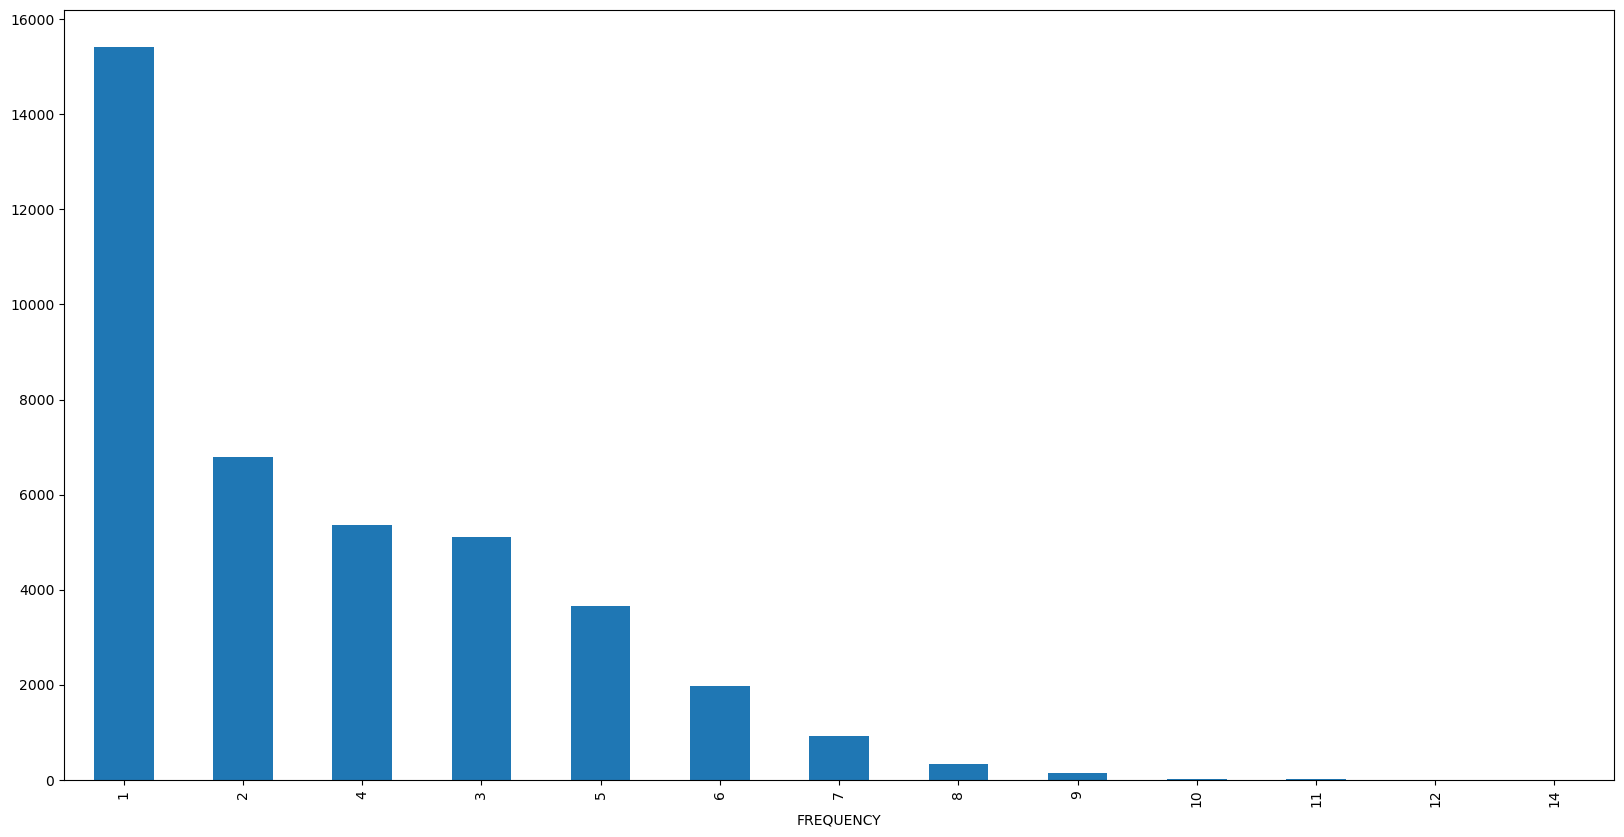

In [24]:
df_rfm.FREQUENCY.value_counts().plot(kind='bar', figsize=(20,10));

In [26]:
#Porcentaje de clientes con 1 sola compra
df_rfm[df_rfm['FREQUENCY'] == 1].shape[0] / total_clientes * 100

38.755403639288225

In [29]:
#Porcentaje de clientes con 5 compras o más
df_rfm[df_rfm['FREQUENCY'] >= 5].shape[0] / total_clientes * 100

17.829496330551926

OBSERVACIONES
- El 39% de los clientes solo ha realizado 1 compra en el último año recogido en el dataset.
- De media los clientes compran entre 2 y 3 veces en el período de un año.
- Solo el 18% de los clientes realizan más de 4 compras anuales.
- El número máximo de compras realizadas por 1 cliente en un año es de 14.

#### Deep Dive sobre la dimensión **MONETARIO**

In [30]:
df_rfm['MONETARY'].describe()

count     39788.000000
mean     197199.799014
std       97079.351001
min         987.580000
25%      118986.225000
50%      204838.690000
75%      274400.522500
max      525590.570000
Name: MONETARY, dtype: float64

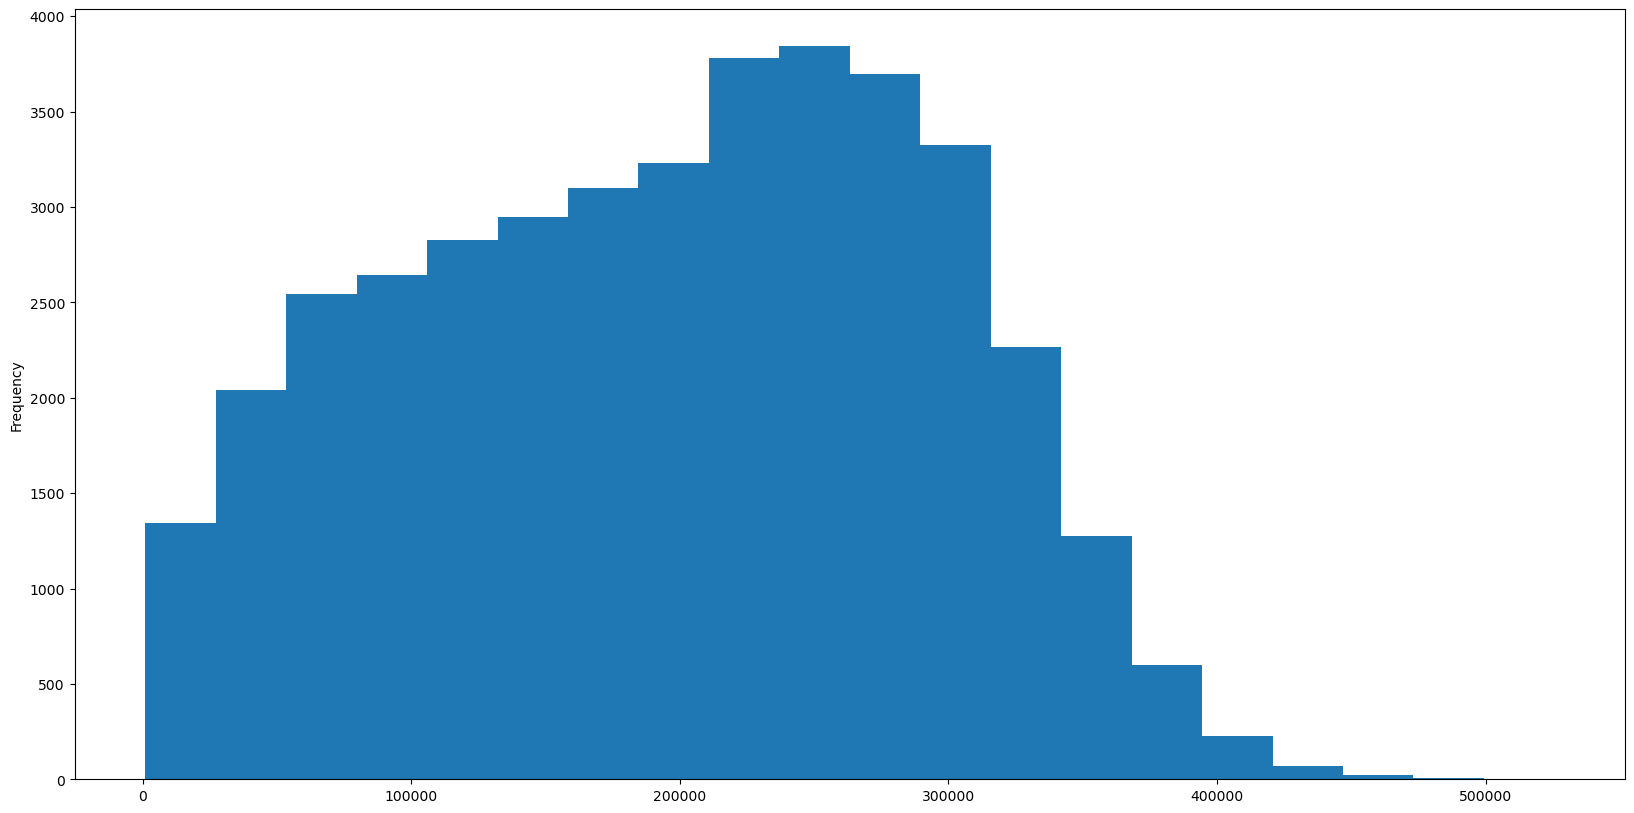

In [33]:
df_rfm['MONETARY'].plot(kind='hist', bins=20, figsize=(20,10));

In [36]:
#Análisis de Paretto para ver qué porcentaje de clientes aporta el 80% de los ingresos
ingreso_total = df_rfm['MONETARY'].sum()
rfm_sort = df_rfm.sort_values("MONETARY", ascending=False)
rfm_sort["MONETARY_ACCUM"] = rfm_sort["MONETARY"].cumsum()
clientes_80 = rfm_sort[rfm_sort["MONETARY_ACCUM"] <= 0.8 * ingreso_total]
print(len(clientes_80))

23719


Observaciones:
- El gasto anual medio por cliente es de 197199.
- El cliente que más se ha gastado en un año suma un total de 525590.
- El número de clientes que generan el 80% de los ingresos es de 23719, esto indica que no existen clientes muy TOP.

#### Exploración de relaciones entre dimensiones

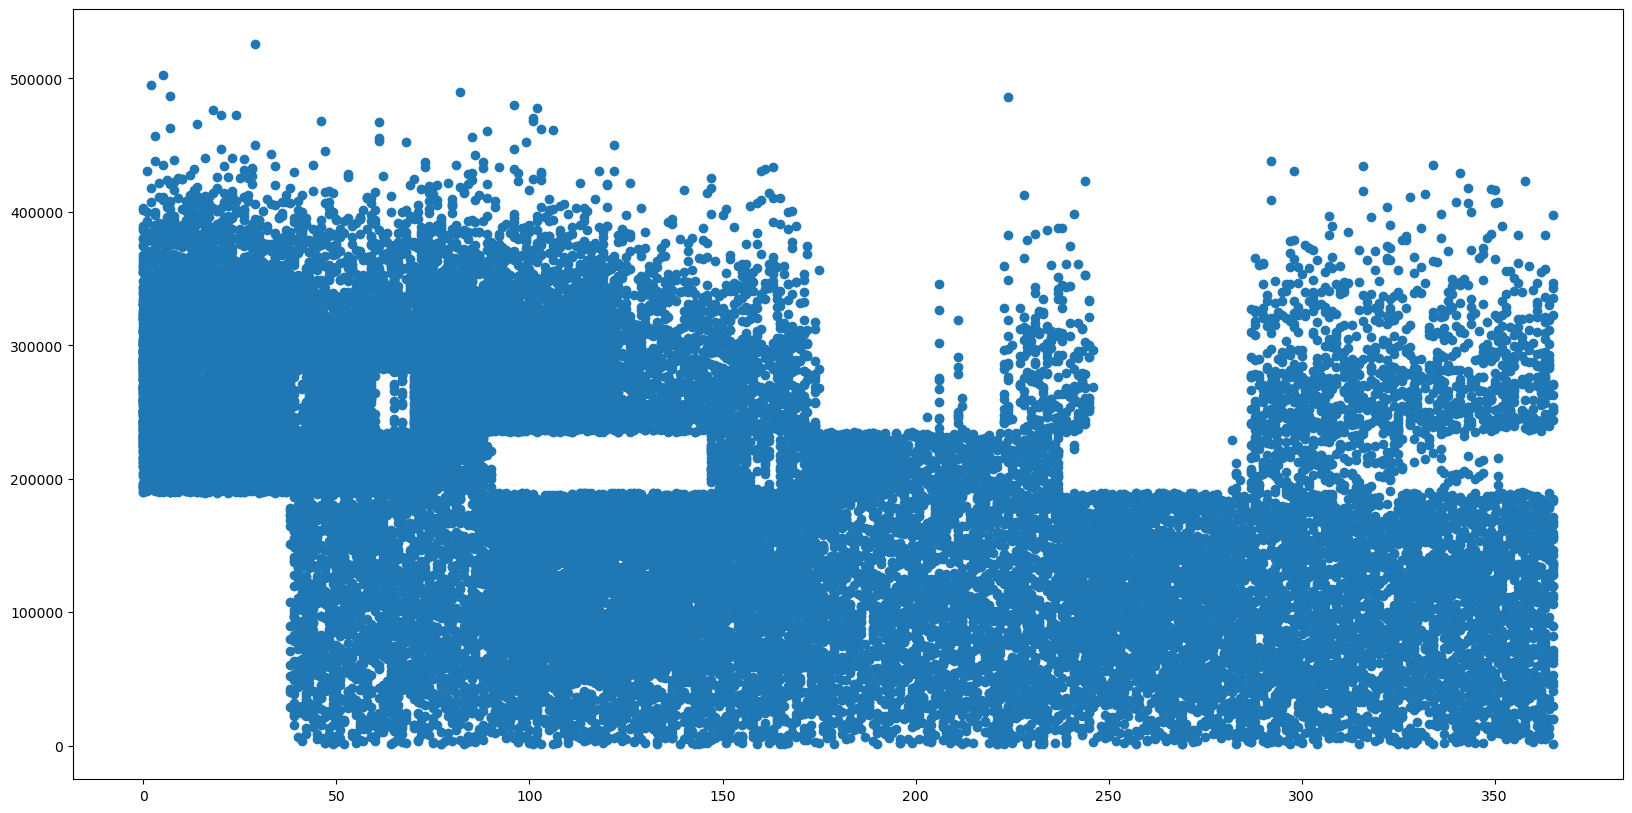

In [41]:
f, ax  = plt.subplots(figsize=(20, 10))

ax.scatter(df_rfm['RECENCY'], df_rfm['MONETARY']);

In [49]:
#Cuántos clientes tienen un RFM_SCORE de 555? Ordenados en descendente segun su valor monetario.
df_rfm[df_rfm['RFM_SCORE'] == '555'].sort_values("MONETARY", ascending=False)

,CUSTOMER_ID,RECENCY,FREQUENCY,MONETARY,R_SCORE,F_SCORE,M_SCORE,RFM_SCORE,RFM_SEGMENT
39787,108931,29,8,525590.57,5,5,5,555,Champions
39786,100159,5,5,502742.76,5,5,5,555,Champions
39785,100810,2,4,494747.48,5,5,5,555,Champions
39778,25457,20,4,472864.04,5,5,5,555,Champions
39777,100978,24,4,472728.80,5,5,5,555,Champions
...,...,...,...,...,...,...,...,...,...
30817,145579,6,6,281833.22,5,5,5,555,Champions
30812,135220,16,7,281815.59,5,5,5,555,Champions
30800,52300,15,8,281766.10,5,5,5,555,Champions
30796,67600,13,7,281752.33,5,5,5,555,Champions


##### VISUALIZACIÓN DE LOS SEGMENTOS RFM

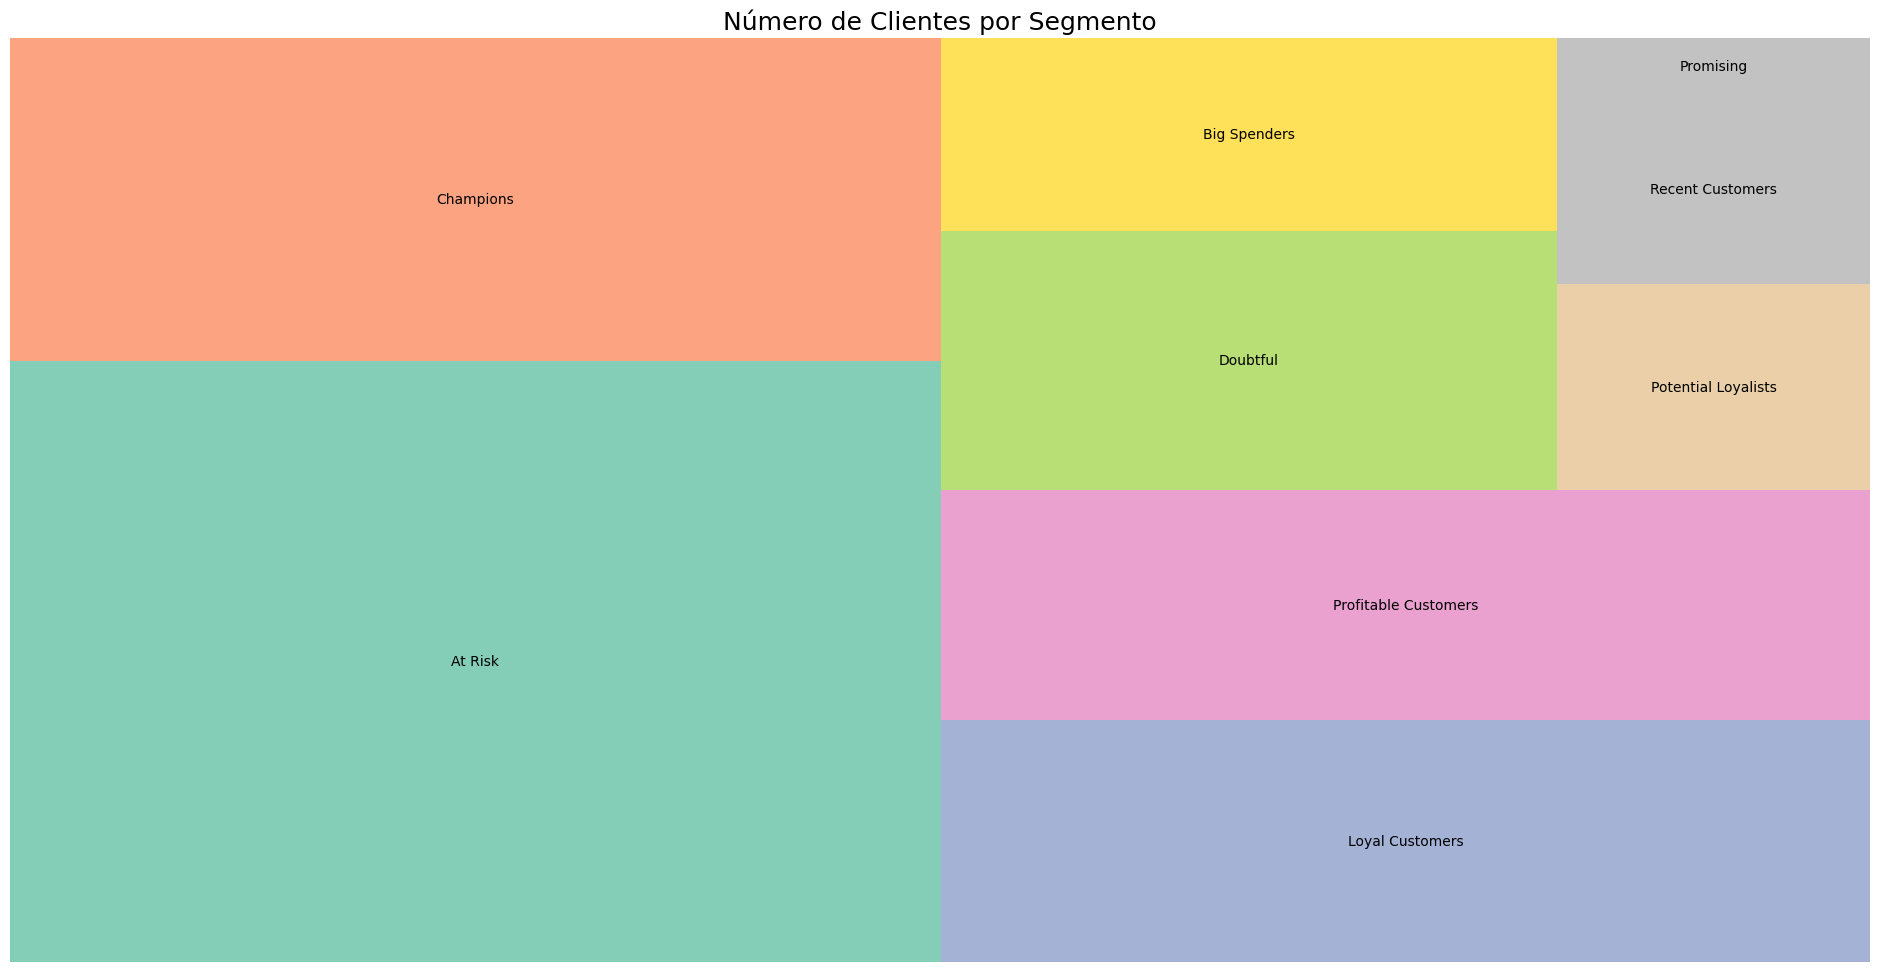

In [50]:
# Contar el número de clientes por segmento
clientes_por_segmento = df_rfm['RFM_SEGMENT'].value_counts()

# Definir una lista de colores con Matplotlib
cmap = plt.cm.Set2(range(len(clientes_por_segmento)))

# Crear el treemap
plt.figure(figsize=(24, 12))
squarify.plot(sizes=clientes_por_segmento.values, label=clientes_por_segmento.index, color=cmap, alpha=0.8)

# Añadir el título y eliminar ejes
plt.title('Número de Clientes por Segmento', fontsize=18)
plt.axis('off')
plt.show()

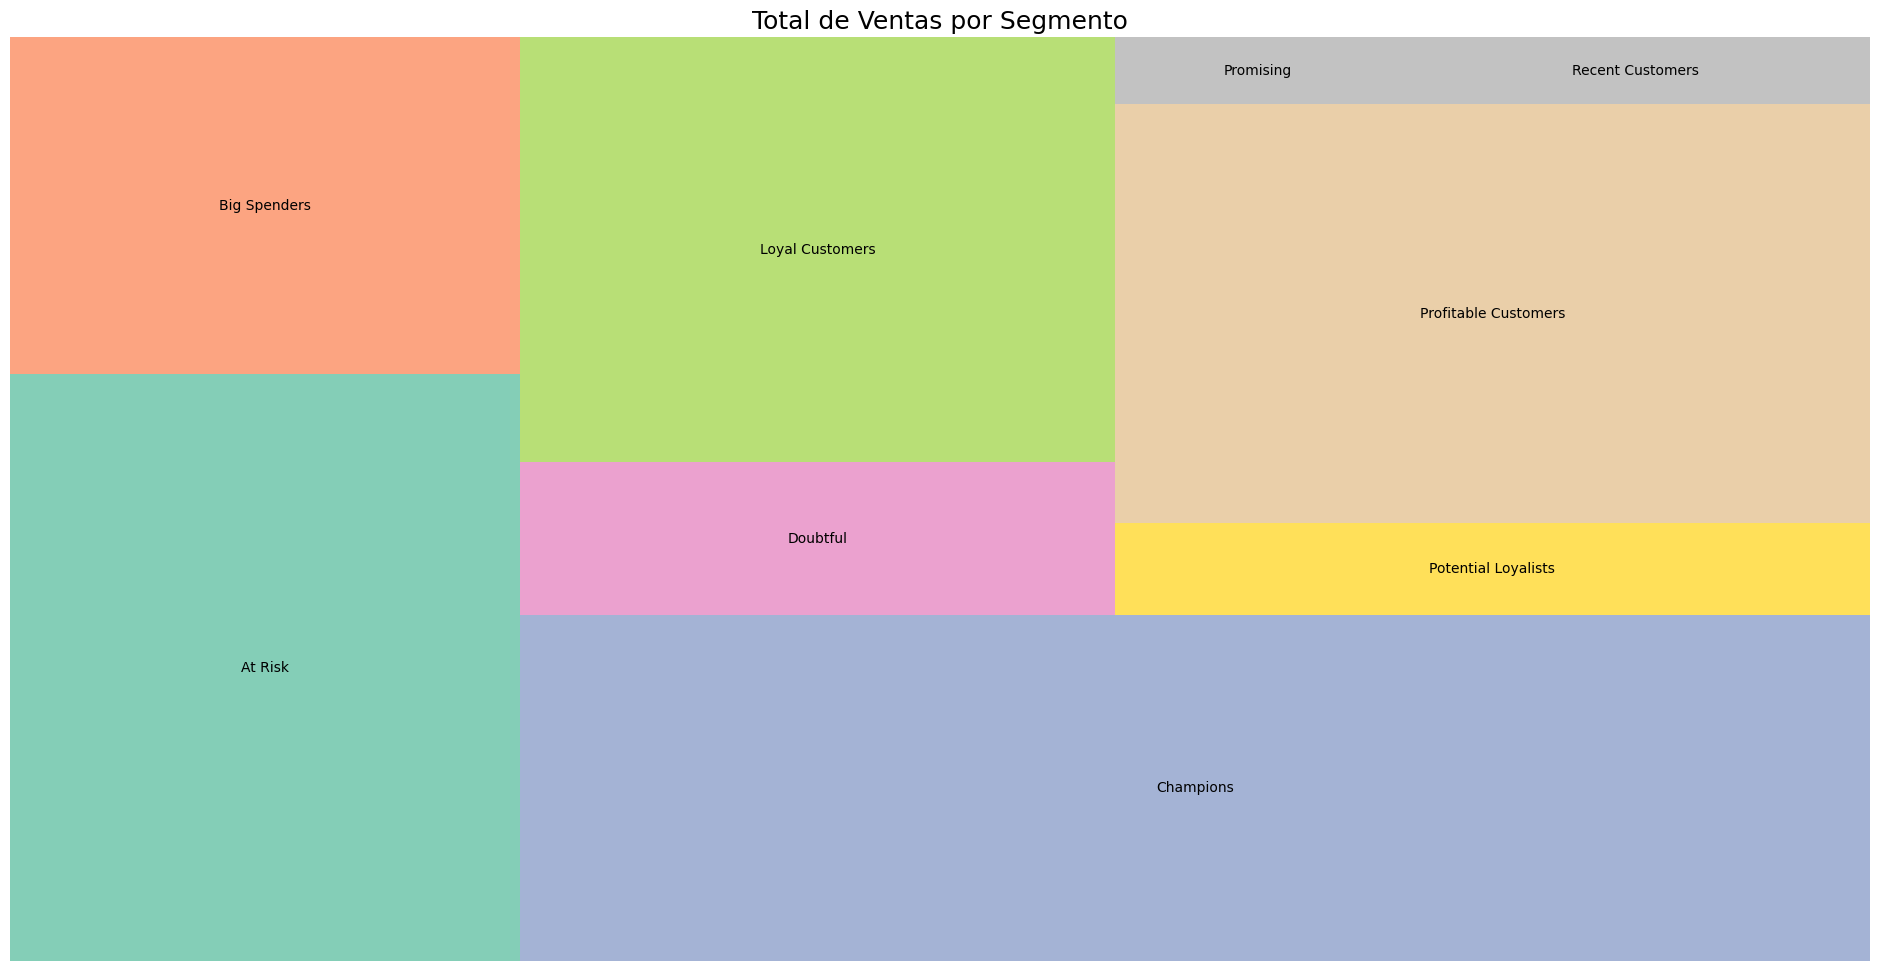

In [47]:
# Representación de Ventas por segmento

# Agrupar y sumar el Total_Venta por segmento (monetary)
import squarify


ventas_por_segmento = df_rfm.groupby('RFM_SEGMENT')['MONETARY'].sum()

# Definir una lista de colores con Matplotlib
cmap = plt.cm.Set2(range(len(ventas_por_segmento)))

# Crear el treemap
plt.figure(figsize=(24, 12))
squarify.plot(sizes=ventas_por_segmento.values, label=ventas_por_segmento.index, color=cmap, alpha=0.8)

# Añadir el título y eliminar ejes
plt.title('Total de Ventas por Segmento', fontsize=18)
plt.axis('off')

plt.show()

Con este análisis, hemos podido segmentar los clientes en distintos grupos, y esto, va a promover la optimización de las campañas de marketing.
Algunas de las medidas que se pueden tomar:

 **1. Campaña de Reactivación:** Dirigida a clientes inactivos o en riesgo, ofreciéndoles incentivos para volver a comprar.
    
 **2. Campaña de Conversión de Compradores Únicos:** Motivar a los clientes que han comprado solo una vez a convertirse en recurrentes mediante ofertas y seguimiento personalizado.
      
 **3. Campaña de Upselling/Cross-selling:** Aumentar el valor promedio de compra mediante paquetes, productos premium y descuentos por gasto mínimo.